# ANÁLISIS DE DATOS

In [2]:
# imports:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest

**RECOPILACIÓN DE DATOS**

* **Import de los datos y crear el Data Frame** 

In [3]:
df = pd.read_csv("../data/raw/internal-link.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## **ANÁLISIS DESCRITIVO**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


**Observaciones:**

1. DIMENSIONES DEL DATASET:

> * Contiene 48895 filas y 16 columnas  
> * Columna target: 'price'

2. VAOLRES NULOS Y NO NULOS:
> * Las columnas con más valores nulos son 'last review', reviews_per_month', la diferencia es de 10.052 datos faltantes  
> * El valor de no nulos en el resto de las columnas varía ligeramente. Estas son 'name' y 'host_name'
> * El resto de columnas contienen todos los valores

3. TIPOS DE DATO:
> * Los datos que aporta el datset son diez columnas de tipo numérico (enteros y decimales) y séis columnas de tipo string (cadenas de texto)  
> * ``dtypes: float64(3), int64(7), object(6)``

### **ANÁLISIS DE COLUMNAS**

In [7]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

1. COLUMNAS Y CARACTERÍSTICAS DE LAS VARIABLES: NUMÉRICOS Y CATEGÓRICOS

NUMÉRICAS:

> Continuas:
> * ``id``, Inuméro identificador del anuncio
> * ``host_id``, identificador del anfitrión que publicó el anuncio
> * ``latitude``, posición geoográfica
> * ``longitude``, posición geográfica
> * ``price``, precio por noche del apartamento anunciado
> * ``reviews_per_month``, promedio de reseñas por mes

> Discretas:
> * ``calculated_host_listings_count``, numero de anuncios que contiene un host 
> * ``availability_365``, número de dias por año que el anuncio está disponible para alquilar
> * ``minimum_nights``, número mínim de noches para reservar el apartamento
> * ``number_of_reviews``, numero total de reseñas que ha recibido el anuncio

CATEGÓRICAS
> * ``host_name``, nombre del anfitrión
> * ``neighbourhood``, barrio
> * ``neighbourhood_group``, grupo de barrios
> * ``room_type``, tipo de habitación


### **Limpieza de DATOS**

ANÁLISIS Y FILTRADO

In [8]:
df.nunique()

id                                48895
name                              47905
host_id                           37457
host_name                         11452
neighbourhood_group                   5
neighbourhood                       221
latitude                          19048
longitude                         14718
room_type                             3
price                               674
minimum_nights                      109
number_of_reviews                   394
last_review                        1764
reviews_per_month                   937
calculated_host_listings_count       47
availability_365                    366
dtype: int64

In [9]:
df_host_id = df.groupby('host_id').size().sort_values(ascending=False)
df_host_id

host_id
219517861    327
107434423    232
30283594     121
137358866    103
12243051      96
            ... 
13561853       1
13562603       1
13563861       1
13564519       1
13541655       1
Length: 37457, dtype: int64

In [10]:
df_host_listings_count = df.groupby('calculated_host_listings_count').size().sort_values(ascending=False)
df_host_listings_count

calculated_host_listings_count
1      32303
2       6658
3       2853
4       1440
5        845
6        570
8        416
7        399
327      327
9        234
232      232
10       210
96       192
12       180
13       130
121      121
11       110
52       104
103      103
33        99
49        98
91        91
87        87
15        75
14        70
23        69
17        68
34        68
65        65
31        62
28        56
18        54
25        50
50        50
47        47
43        43
20        40
39        39
37        37
32        32
30        30
29        29
27        27
26        26
21        21
19        19
16        16
dtype: int64

**Observaciones:**

> * Hay 4 anfitriones que tienen más de 1000 anuncion publicados:  
> calculated_host_listings_count, indicando el número de anuncios que contiene un host. El mayor número de anunciós publicados que tiene un host es 32.303.

> * También hay más de 4 host_id ue aparecen más de 100 veces:  
> host_id, es el identificador del anfitrión que publicó el anuncio. El mayor número de veces que aparece un host es 327.

#### **Distribuciones decomparación**

*Comparo los datos originales de 'price', 'minimum_nights' y 'host_id' con un filtrado de columnas:*

In [11]:
df_filtered = df[(df['minimum_nights'] <=365) & (df['price'] <=1000) & (df['availability_365'] <=100)]
df_filtered

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
10,5295,Beautiful 1br on Upper West Side,7702,Lena,Manhattan,Upper West Side,40.80316,-73.96545,Entire home/apt,135,5,53,2019-06-22,0.43,1,6
11,5441,Central Manhattan/near Broadway,7989,Kate,Manhattan,Hell's Kitchen,40.76076,-73.98867,Private room,85,2,188,2019-06-23,1.50,1,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


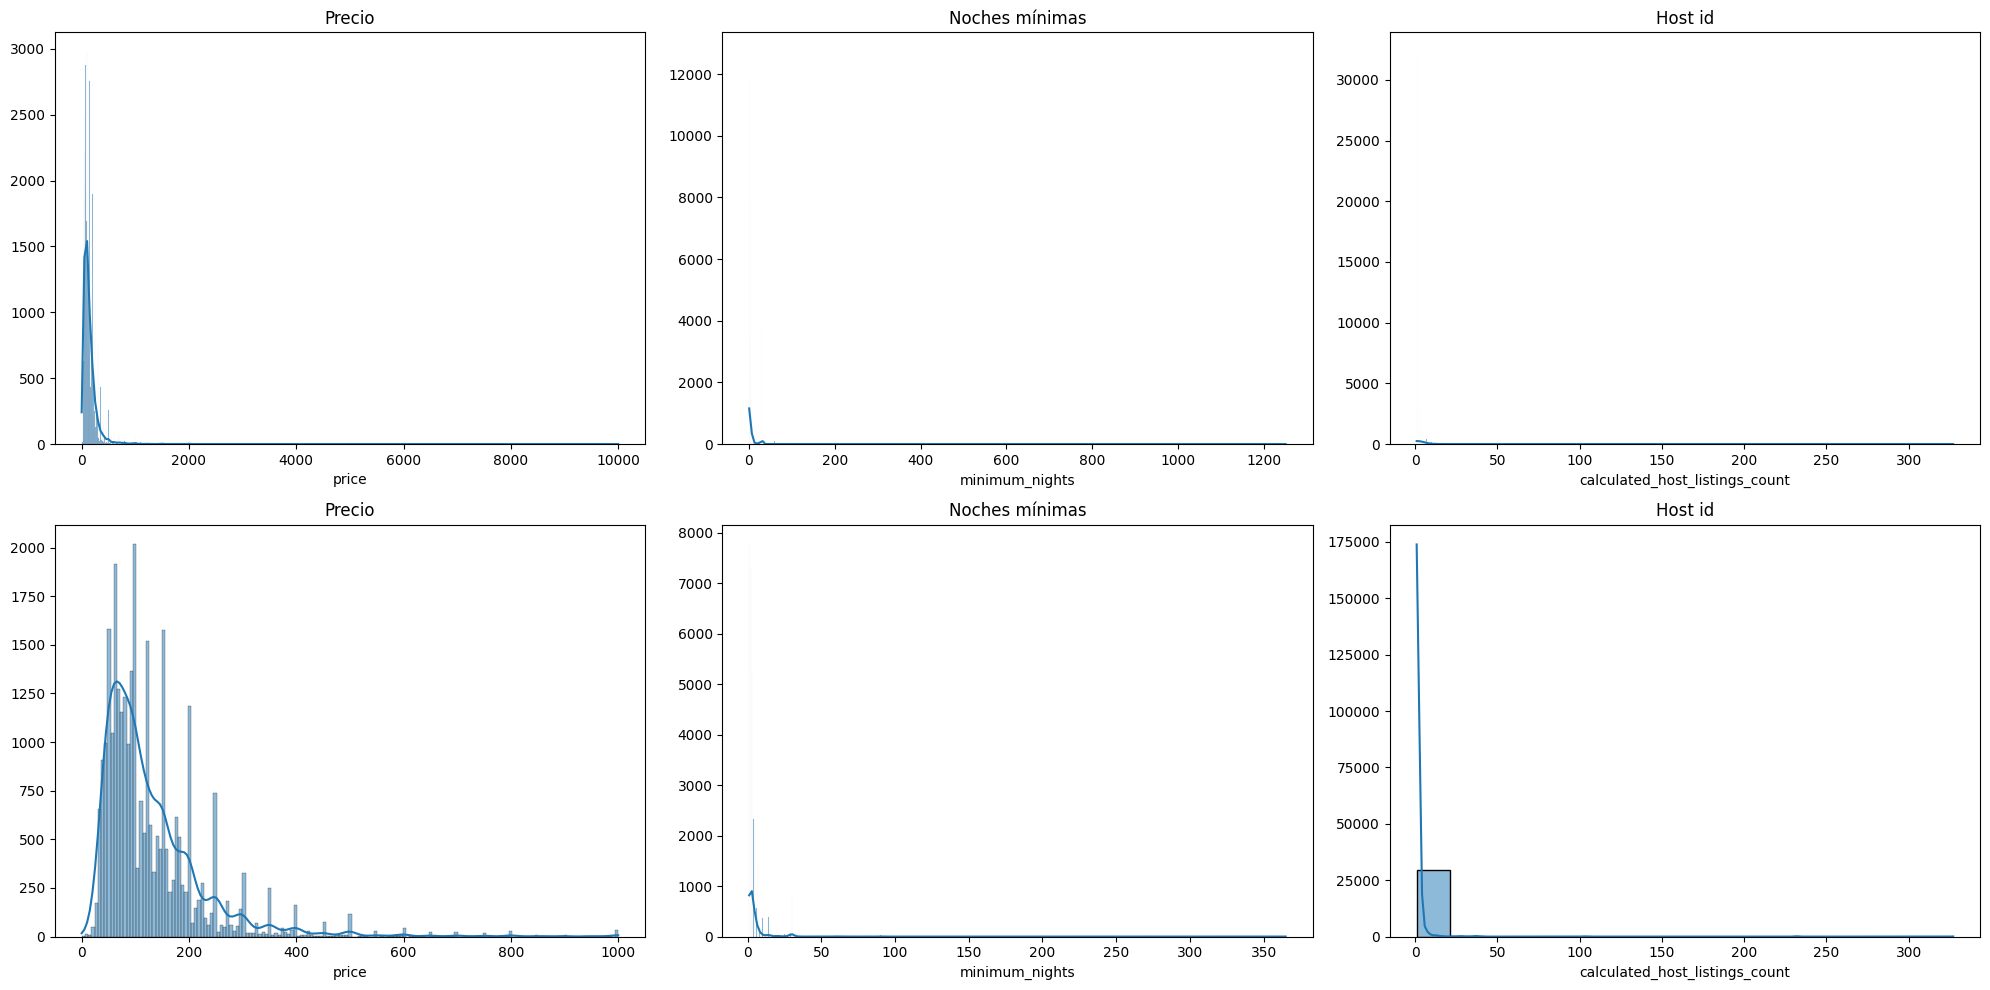

In [12]:
figs, axis = plt.subplots(2, 3, figsize=(20, 10))

sns.histplot(ax=axis[0, 0], data=df, x='price', kde=True).set(title='Precio', ylabel=None)
sns.histplot(ax=axis[0, 1], data=df, x='minimum_nights', kde=True).set(title='Noches mínimas', ylabel=None)
sns.histplot(ax=axis[0, 2], data=df, x='calculated_host_listings_count', kde=True).set(title='Host id', ylabel=None)
sns.histplot(ax=axis[1, 0], data=df_filtered, x='price', kde=True).set(title='Precio', ylabel=None)
sns.histplot(ax=axis[1, 1], data=df_filtered, x='minimum_nights', kde=True).set(title='Noches mínimas', ylabel=None)
sns.histplot(ax=axis[1, 2], data=df_filtered, x='calculated_host_listings_count', kde=True).set(title='Host id', ylabel=None)


plt.tight_layout()

**Observaciones de los sesgos de las variables:**
> * ``price``, los valores la mayoría son valores bajos a 0 pero también se encuentran algunos valores altos indicando que algunos apartamentos tienen un precio elevado y sesgan los datos hacia la derecha
> * ``minimum_nights``, la mayoria de la data está concentrada enre 1 y 2 noches lo cuál indica que la mayor parte de los alquileres es de corta estancia y se observa otro pico alrededor las 30 noches  
En el gráfico originial hay valores mucho más altos que pueden ser posibles outliers
> * ``calculated_hist_listings_count``, existen mcuhos más propietarios que tienen 1 o 2 propiedades aunque si algunos llegan a tener más de 300 y más de 30.000 publicaciones

# **Limpieza de Datos: Eliminar información irrelevante**

In [13]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

**Conclusión:**

1. VARIABLES DESCARTADAS
> *``Función: .drop()``* *para eliminar las columnas que no se utilizarán para en este análisis*
> * Las variables relacionadas con las 'reviews' también son eliminadas porque no aportan datos concretos al análisis del precio. Además, ``'last_review'``, ``'reviews_per_month'``, ``'number_of_reviews'``: contienen varios NaNs
> * Hay diferencias entre el número de valores unicos que idefntfican a la persona propietaria del airbnb (``'name'``, ``'host_id'`` y ``'host_name'``). Esto deberían de tener el mismo número si la lista fuese enteramente de propietarios únicos pero algunos propietarios tienen más de un host_id ya que tienen más de un anuncio publicado como indica ``'calculated_host_listening_count'``. Se descartan esas columnas además de la columna ``'id'`` para identificar al propietario ya que no es necesario identificar el nombre del propietario o del anuncio para este análisis.
> * ``'longitude'`` y ``'longitude'``, las descarto porque las variables ``'neighbourhood'`` y ``'neighbourhood_group'`` ya aportan la localización de los apartamentos. Me quedo solo con la columna 'neighbourhood_group'

2. APLICO UN FILTRADO DE DATOS
> * ``'price'``, en precios diferentes a 0$ por noche
> * ``'minimum_nights'``, elimino los anuncios que no aportan disponibilidad para reservar noches ya que algunos tienen 0 disponibilidad
> * ``'availability_365'``, es el alquiler mínimo de noches menor a 365 pero hay varios apartamentos que tienen 0 días de disponibilidad quizás porque ya no ofrecen más serivicio de hospedage. Se eliminan del df para obtener un análisis de los apartamentos en activo.
> * ``'neighbourhood_group'``, 
> * ``'room_type'``, 

**.drop() de las variables que se descartan:**

In [14]:
df.drop(['id','name','reviews_per_month','number_of_reviews','host_name','host_id','last_review','longitude','latitude','calculated_host_listings_count','neighbourhood'], axis=1, inplace=True)
df

,neighbourhood_group,room_type,price,minimum_nights,availability_365
0,Brooklyn,Private room,149,1,365
1,Manhattan,Entire home/apt,225,1,355
2,Manhattan,Private room,150,3,365
3,Brooklyn,Entire home/apt,89,1,194
4,Manhattan,Entire home/apt,80,10,0
...,...,...,...,...,...
48890,Brooklyn,Private room,70,2,9
48891,Brooklyn,Private room,40,4,36
48892,Manhattan,Entire home/apt,115,10,27
48893,Manhattan,Shared room,55,1,2


**Filtrado de columnas para la limpieza de datos:**

In [15]:
price_zero = (df['price'] == 0).sum()
min_max_365 = (df['minimum_nights'] >= 365).sum()
zero_availability = (df['availability_365'] == 0).sum()

In [16]:
df_filtered_one= df[(df['price'] == 0) | (df['minimum_nights'] >= 365) | (df['availability_365'] == 0)]
df_filtered_one = df_filtered_one[['price','minimum_nights', 'availability_365']]
df_filtered_one

,price,minimum_nights,availability_365
4,80,10,0
6,60,45,0
8,79,2,0
14,120,90,0
20,299,3,0
...,...,...,...
48550,45,1,0
48731,111,8,0
48756,129,2,0
48760,46,1,0


In [17]:
# NO ENTIENDO EL RESULTADO DE ESTE CODIGO

df[df['price']==0].sum()

neighbourhood_group    BrooklynBronxBrooklynBrooklynBrooklynBrooklynB...
room_type              Private roomPrivate roomPrivate roomPrivate ro...
price                                                                  0
minimum_nights                                                        81
availability_365                                                    1330
dtype: object

In [18]:
df_filtered_one.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17578 entries, 4 to 48779
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             17578 non-null  int64
 1   minimum_nights    17578 non-null  int64
 2   availability_365  17578 non-null  int64
dtypes: int64(3)
memory usage: 549.3 KB


**Observaciones:**

In [19]:
print('Número de filas con precio 0$ por noche:', price_zero)
print('Número de filas con el minimo de noches requerido para alquilar la estancis es mayor a 365 dias:', min_max_365 )
print('Número de filas con disponibilidad 0 anual:', zero_availability )

Número de filas con precio 0$ por noche: 11
Número de filas con el minimo de noches requerido para alquilar la estancis es mayor a 365 dias: 43
Número de filas con disponibilidad 0 anual: 17533


**Conclusión:**

> **LIMPIEZA DEL DATA FRAME:**
> * Interpreto que si los anuncios tienen disponibilidad 0 anual es que no están activos así que elimino esas filas, también las que tienen minimo de noches a 0 o mayor a 365 y las que ofrecen el precio a 0$


In [20]:
df = df.drop(df[df['availability_365'] == 0].index)

> Compruebo si siguen quedando otras columnas con valores a cero y elimino la fila del anuncio

In [21]:
price_zero, min_max_365

(np.int64(11), np.int64(43))

In [22]:
df = df.drop(df[df['price'] == 0].index)

In [23]:
df[(df['availability_365'] != 0) & (df['minimum_nights'] <= 365)]

,neighbourhood_group,room_type,price,minimum_nights,availability_365
0,Brooklyn,Private room,149,1,365
1,Manhattan,Entire home/apt,225,1,355
2,Manhattan,Private room,150,3,365
3,Brooklyn,Entire home/apt,89,1,194
5,Manhattan,Entire home/apt,200,3,129
...,...,...,...,...,...
48890,Brooklyn,Private room,70,2,9
48891,Brooklyn,Private room,40,4,36
48892,Manhattan,Entire home/apt,115,10,27
48893,Manhattan,Shared room,55,1,2


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31354 entries, 0 to 48894
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   neighbourhood_group  31354 non-null  object
 1   room_type            31354 non-null  object
 2   price                31354 non-null  int64 
 3   minimum_nights       31354 non-null  int64 
 4   availability_365     31354 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.4+ MB


**Observaciones:**

> * Al filtrar los apartamentos sin disponibilidad anual, nos quedan 31354 filas. La diferencia respecto a los datos orginales es de 17.542 filas

# **Análisis de Variables**


### **Variable objetivo / target**

* 'price', depende el precio por noche de la disponibilidad del apartamento?

### **Variables predictorias**

>>> 1. ``'availability_365'``¿los apartamentos con mayor disponibilidad durante el año son más costosos o más económicos?
>>> 2. ``'neighbourhood_group'``¿dependiendo la localización cuánto varia el precio?
>>> 3. ``'room_type'`` ¿dependiendo del tipo de apartamento el precio es más variante?
>>> 4.  ``'minimum_nights'`` ¿los apartamentos temporales (1-2 días) son más costosos o más económicos?

### **Análisis de Variables Univariante**

*Definición: Se distinguen entre dos tipos, nuéricas y categóricas. Son datos estadístios de un conjunto de observaciones de un atributo. Análisis columna a columna, analar una variable solamente. Nos ayuda a ver la distribución de los valores y sus medidas* 

* **Análisis de variables Categóricas**

1. 'neighbourhood_group',
2. 'neighbourhood',
3. 'room_type',

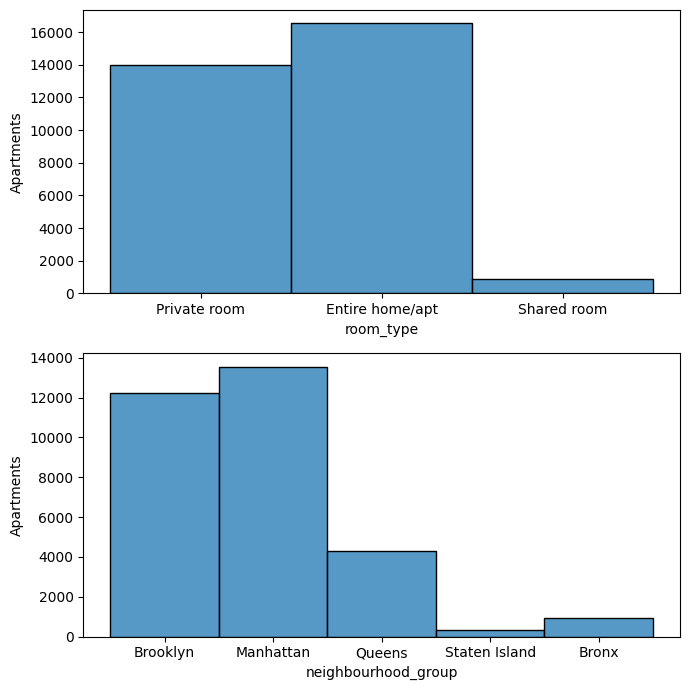

In [25]:
fig, axis = plt.subplots(2, figsize=(7, 7))
sns.histplot(ax=axis[0], data=df, x="room_type").set(ylabel='Apartments')
sns.histplot(ax=axis[1], data=df, x="neighbourhood_group").set(ylabel='Apartments')

plt.tight_layout()
plt.show()

**Conclusiones:**

> * La mayoria de estancias ofrecidas son apartamentos enteros y habitaciones privadas. Hay poca diferencia entre ellas
> * Los dos barrios donde se forecen más alquileres son Brooklyn y Manhattan, el que menos ofrece es Staten Island

* **Análisis de variables Numéricas** 

1. ``'price'``, precio por noche en dólares
2. ``'availability_365'``, días disponibles para reservar el apartamento por año
3. ``'minimum_nights'``, mínimo de noches para poder reservar el apartamento

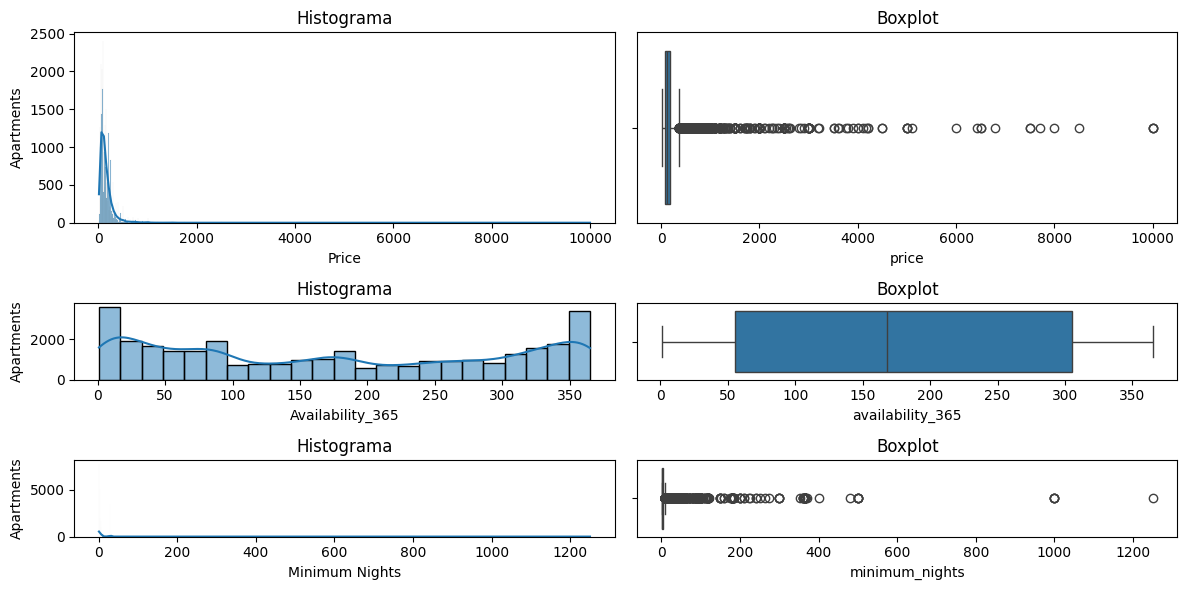

In [26]:
fig, axis = plt.subplots(3, 2, figsize=(12, 6), gridspec_kw={'height_ratios': [5, 2, 2]})

sns.histplot(ax=axis[0, 0], data=df, x="price", kde=True).set(title='Histograma', xlabel='Price', ylabel='Apartments')
sns.boxplot(ax=axis[0, 1], data=df, x="price").set(title='Boxplot', ylabel=None)
sns.histplot(ax=axis[1, 0], data=df, x="availability_365", kde=True).set(title='Histograma', xlabel='Availability_365', ylabel='Apartments')
sns.boxplot(ax=axis[1, 1], data=df, x="availability_365").set(title='Boxplot', ylabel=None)
sns.histplot(ax=axis[2, 0], data=df, x="minimum_nights", kde=True).set(title='Histograma', xlabel='Minimum Nights', ylabel='Apartments')
sns.boxplot(ax=axis[2, 1], data=df, x="minimum_nights").set(title='Boxplot', ylabel=None)



plt.tight_layout()
plt.show()

**Observaciones:**


HISTOGRAMAS (Con qué frecuencia aparecen los valores):
> * Hay dos picos de disponibilidad anual, uno de unos 20 dias y otro el año entero. Esto representa que hay gran cantidad de apartamentos que se ofrece o por pocos dias o todo el año
> *  la mayoría de los apartamentos ofrecen un pecio de hasta 1000 por noche aproximadamente
> * El mínimo de noches se centra cerca del 1 y 2 en la mayoria de los anuncios

BOXPLOTS (Datos Estadísiticos: Dispersión y Valores atípicos):
> * Las variables con más outliers (valores atípicos) son minimum_nights y price. Divido price en rangos de precios para tratar mejor los datos buscando que tipo de habitación se ajusta a un rango de precio respecto al minimo de noches por reserva.
> * La media de los dias disponibles por año ronda los 160 días de alquiler ofrecido por año


In [27]:
df[df['minimum_nights'] >50]

,neighbourhood_group,room_type,price,minimum_nights,availability_365
36,Brooklyn,Private room,35,60,365
61,Manhattan,Entire home/apt,375,180,180
106,Brooklyn,Entire home/apt,125,90,137
245,Manhattan,Entire home/apt,110,200,140
349,Brooklyn,Entire home/apt,100,90,365
...,...,...,...,...,...
48145,Brooklyn,Entire home/apt,150,90,91
48312,Bronx,Shared room,25,90,190
48325,Brooklyn,Private room,70,60,156
48368,Manhattan,Private room,150,60,215


**División del precio por rangos:**


> Concluyo que de 0-60$ por noche se ofrecen alquiler de habitaciones compartidas y privadas, de 60 - 80$ habitaciones privadas, de 100 a 190$ y habitaciones privadas o más apartamentos enteros y así creo la división de precio spor raqngo incluyendo valores altos para no perder los outlaiers

FUNCIÓN:
``pd.cut``

In [28]:
# Creo una nueva columna categórica del precio dividio por rangos
bins = [0, 60, 100, 190, 600, 1000,10000]
labels = [1, 2, 3, 4, 5, 6]
df['price_filtered'] = pd.cut(df['price'], bins=bins, labels=labels, include_lowest=True)

df['price_filtered'].value_counts().sort_index()

price_filtered
1    6123
2    8574
3    9071
4    6970
5     444
6     172
Name: count, dtype: int64

**Conclusión:** 

> * El mayor número de apartamentos de ofrecen por precios de rango 2 (60-100$) y 3(100-190$)
> * Los rangos 1 (0-60$) y 4(190-600$) contienen un numero de informacion similar.
> * Hay pocos apartaemtnos que se alquilen en el rango de precio 5 (1000-10000$ por noche)

### **Análisis de Variables Multivariante**

Analizar la relación entre variables según sus características:

* **Análisis de variables Numérica-Numérica**

Utilizo ``'price'`` como variable numérica.

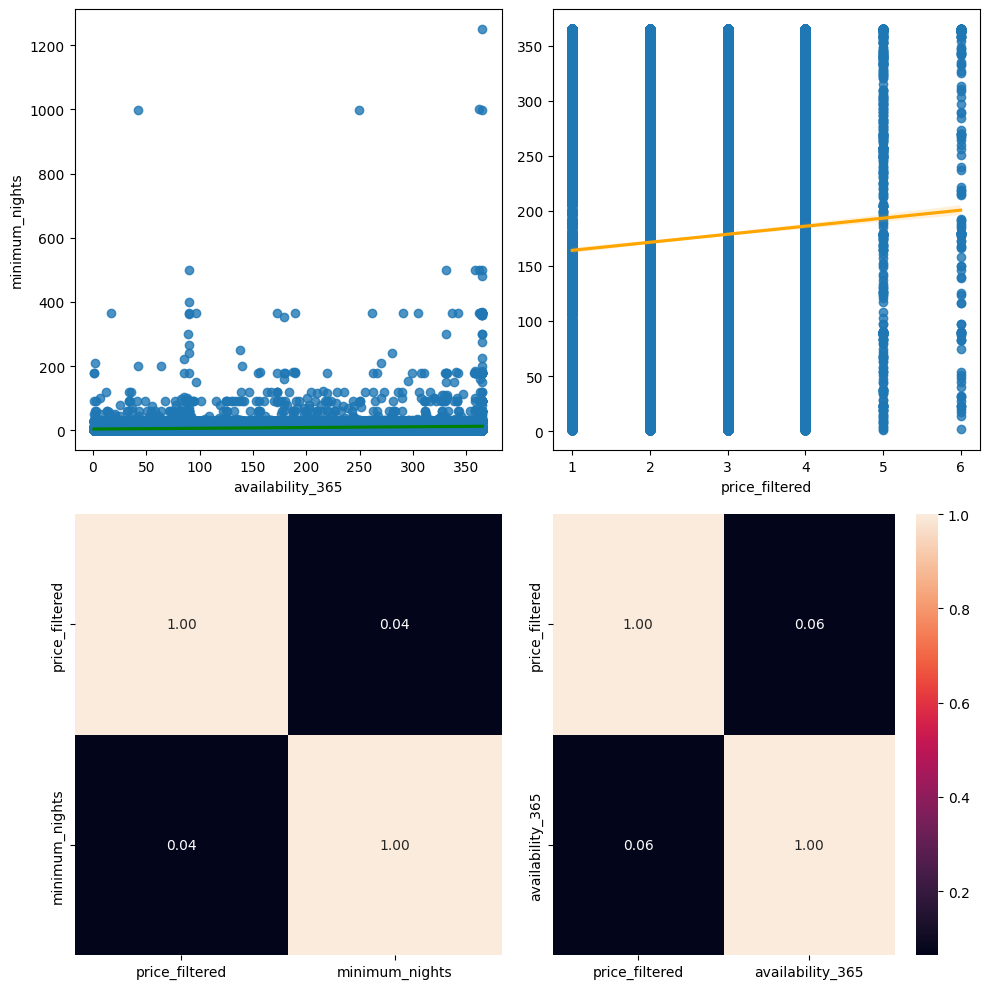

In [29]:
# Genero las correlaciones entre la variable target y las predictoras numéricas
corr_price_availability = df[["price_filtered", "availability_365"]].corr()
corr_price_minimum_nights = df[['price_filtered', 'minimum_nights']].corr()

# Creo un diagrama de dispersión múltiple
fig, axis = plt.subplots(2, 2, figsize=(10, 10))

sns.regplot(ax=axis[0, 0], data=df, x="availability_365", y="minimum_nights", line_kws={'color': 'green'})
sns.heatmap(ax=axis[1, 0], data=corr_price_minimum_nights, annot=True, fmt=".2f", cbar=False)

sns.regplot(ax=axis[0, 1], data=df, x="price_filtered", y="availability_365", line_kws={'color': 'orange'}).set(ylabel=None)
sns.heatmap(ax=axis[1, 1], data=corr_price_availability, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

**Obervaciones:**

> * Correlación negativa entre precio y reviews por mes entonces los aparmentos más caros generan menos reviews mensuales
> * Correlación positiva entre precio y noches mínima y en este caso las estancias más largas estan asociadas a precios más altos


XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

VIOLIN PLOT 

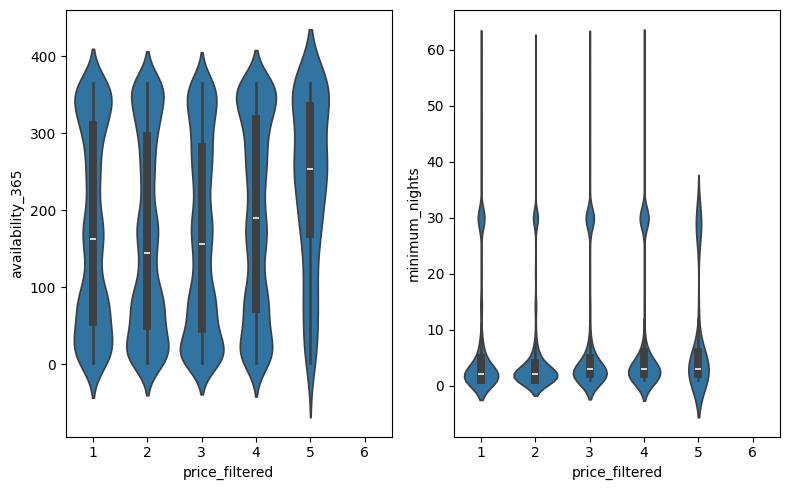

In [44]:
fig, axis = plt.subplots(1, 2, figsize=(8, 5))

sns.violinplot(ax=axis[0], data=df, x='price_filtered', y='availability_365')
sns.violinplot(ax=axis[1], data=df, x='price_filtered', y='minimum_nights')

plt.tight_layout()
plt.show()

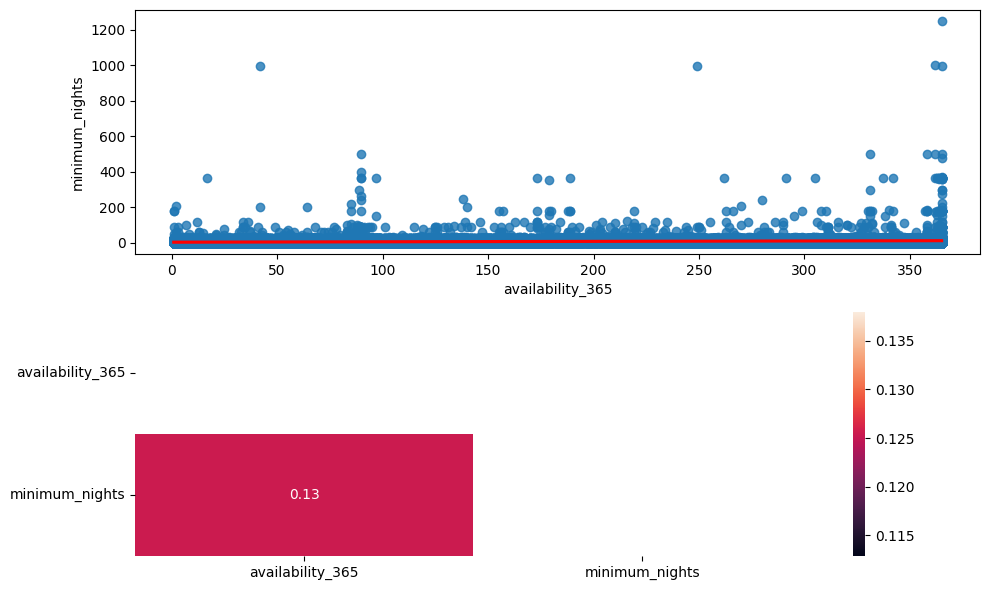

In [31]:
# CORRELACIÓN:

corr_df = df[[ 'availability_365', 'minimum_nights']].corr()
mask_corr = np.triu(np.ones_like(corr_df, dtype=bool))

fig, axis = plt.subplots(2, 1, figsize=(10, 6))
sns.regplot(ax=axis[0], data=df, x="availability_365", y="minimum_nights", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1], data=corr_df, mask=mask_corr, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

**Observaciones:**

> * XX
> * XX

* **Análisis de variables Categórica-Categórica**

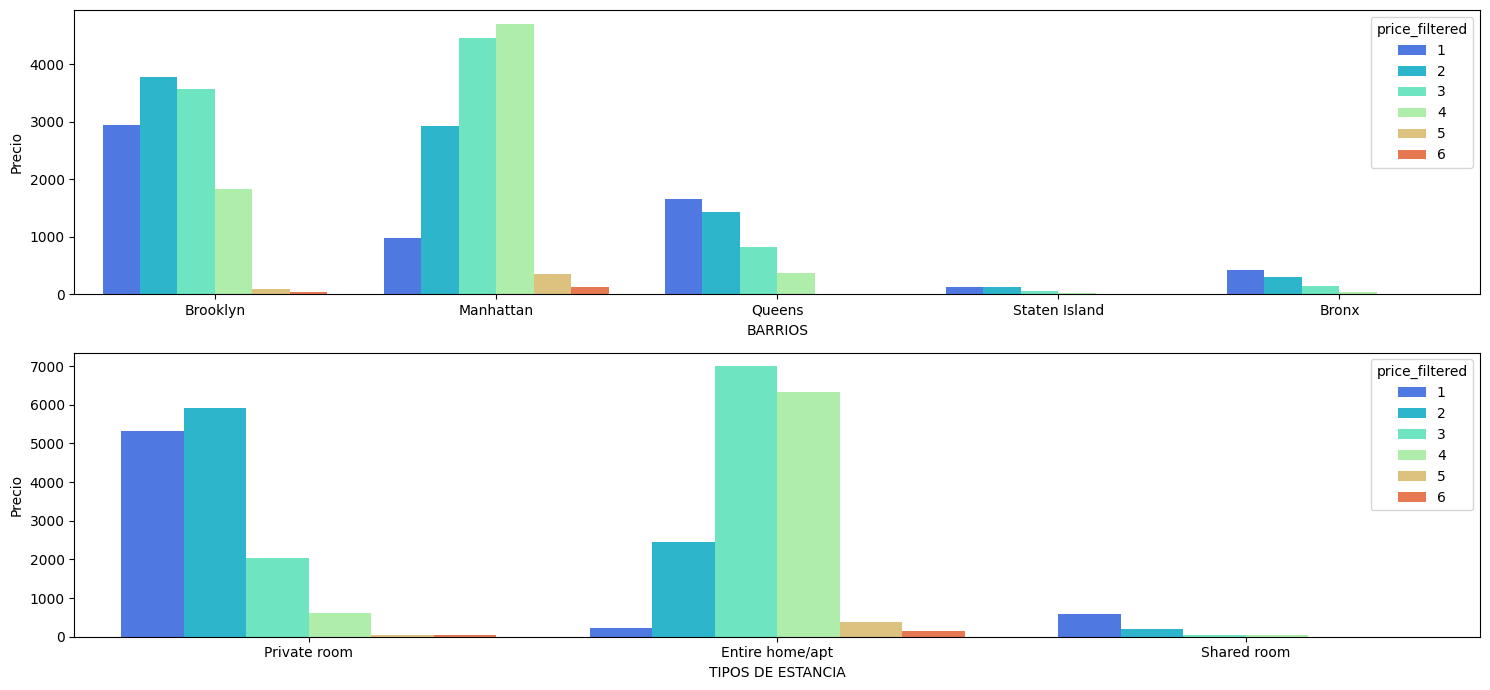

In [32]:
fig, axis = plt.subplots(2, figsize=(15, 7))

sns.countplot(ax=axis[0], data=df, x="neighbourhood_group", hue="price_filtered", palette='rainbow').set(xlabel='BARRIOS', ylabel='Precio')
sns.countplot(ax=axis[1], data=df, x="room_type", hue="price_filtered", palette='rainbow').set(xlabel='TIPOS DE ESTANCIA', ylabel='Precio')
                                        

plt.tight_layout()
plt.show()

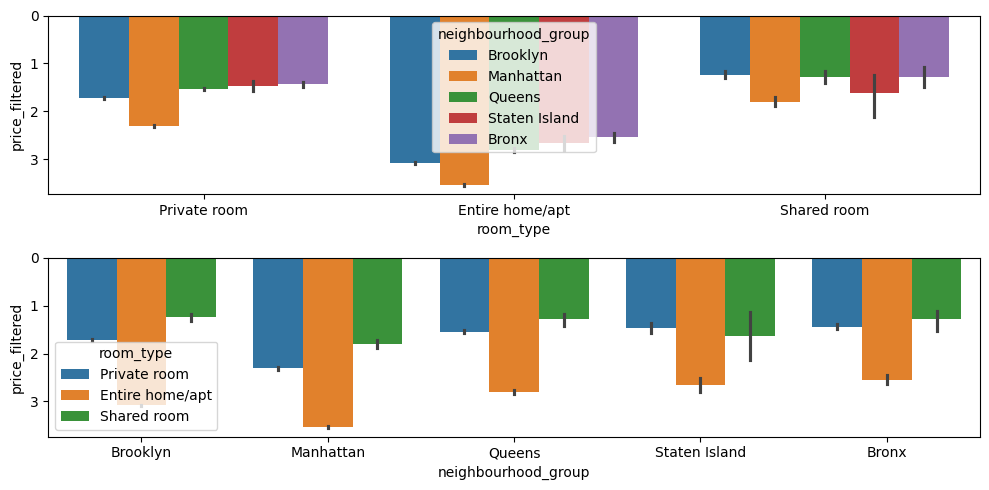

In [33]:
fig, axis = plt.subplots(2,1, figsize=(10, 5))

sns.barplot(ax=axis[0], data=df, x="room_type", y="price_filtered", hue="neighbourhood_group")
sns.barplot(ax=axis[1], data=df, x="neighbourhood_group", y="price_filtered", hue="room_type")

plt.tight_layout()
plt.show()

In [34]:
#TODO para justificar describe().T
df['minimum_nights'].sort_values(ascending=False)

5767     1250
2854     1000
26341     999
38664     999
13404     999
         ... 
40323       1
40325       1
40326       1
40331       1
4274        1
Name: minimum_nights, Length: 31354, dtype: int64

In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,31354.0,162.091822,254.444750,10.0,70.0,112.0,189.0,10000.0
minimum_nights,31354.0,8.338426,23.838961,1.0,2.0,3.0,5.0,1250.0
availability_365,31354.0,175.834439,126.195374,1.0,55.0,168.0,305.0,365.0


oBSERVACIONES PRICE
lat y long - cuidado al interpretar columns
price statistics - centrarse en cuartiles(analisis) - Entre 0 y 75% = 189 



**Observaciones:**



**Análisis de correlaciones factorizadas:**


* **Factorizar las variables categóricas:**

In [36]:
#TODO explain factorize method
# FACTORIZAR PRECIO?¿

In [45]:
df["room_type_n"] = pd.factorize(df["room_type"])[0]
df["neighbourhood_group_n"] = pd.factorize(df["neighbourhood_group"])[0]


**Correlación de las variables categóricas:**

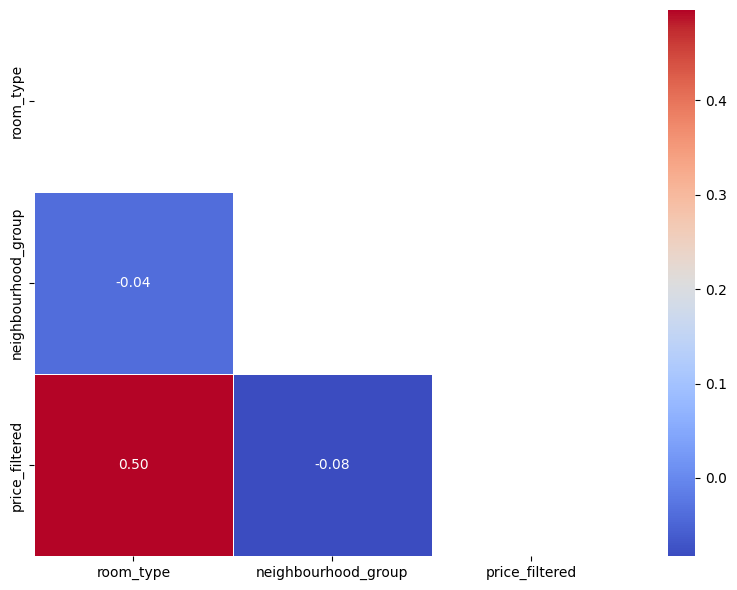

In [46]:
cols = ["room_type", "neighbourhood_group", "price_filtered"]
df_encoded = df[cols].apply(LabelEncoder().fit_transform)

# Calculamos la correlación
corr = df_encoded.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, axis = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

In [47]:
df["room_type"] = pd.factorize(df["room_type"])[0]
df["neighbourhood_group"] = pd.factorize(df["neighbourhood_group"])[0]
df["price_filtered"] = pd.factorize(df["price_filtered"])[0]

* **Análisis de variables Numérica-Categórica**

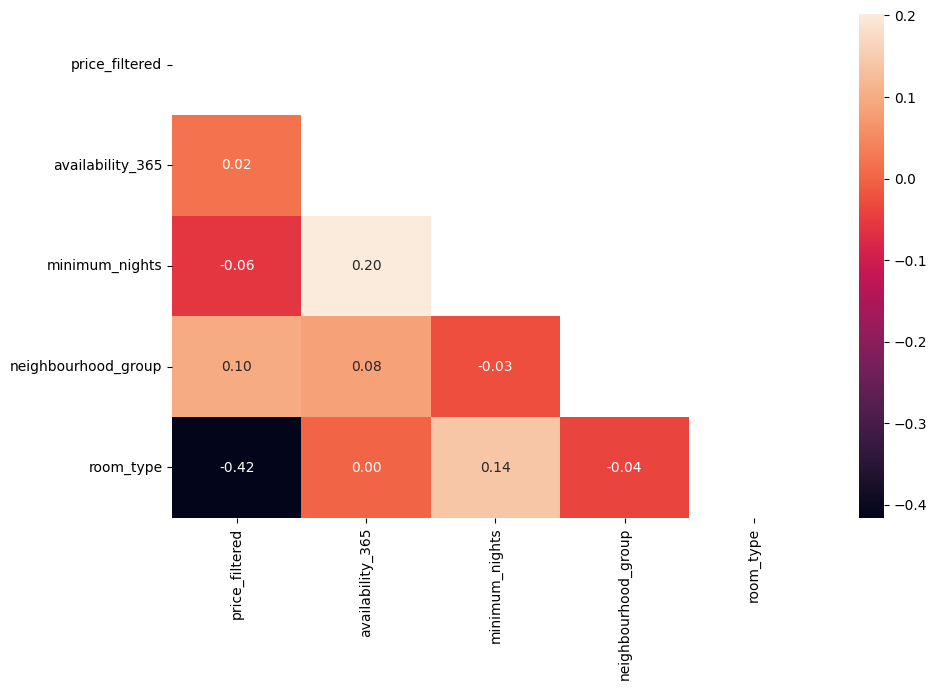

In [48]:
# CORRELACIÓN

corr = df[['price_filtered', 'availability_365', 'minimum_nights','neighbourhood_group','room_type']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

**Observaciones:** 

REVISAR -------------------------------------------
> * La ubicación geográfica es un factor clave en la variación del precio
> * Estancias mínimas cortas es la variable en más correlación con el precio
> * El número de anuncios por host y el minimo de noches tienen un valor similar de correlación por lo que podemos deducir que cada host usa más o menos los mismos servicios en sus anuncios. 

## **Ingeniaria de características:**

### **Análisisde ouliers**

In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
neighbourhood_group,30783.0,0.854303,0.903497,0.0,0.0,1.0,1.0,4.0
room_type,30783.0,0.578436,0.547063,0.0,0.0,1.0,1.0,2.0
price,30783.0,145.531365,113.940672,10.0,70.0,110.0,185.0,822.0
minimum_nights,30783.0,6.858006,10.049818,1.0,2.0,3.0,5.0,60.0
availability_365,30783.0,174.608193,125.971738,1.0,54.0,166.0,303.0,365.0
price_filtered,30783.0,1.408115,1.131068,0.0,0.0,1.0,2.0,4.0
room_type_n,30783.0,0.578436,0.547063,0.0,0.0,1.0,1.0,2.0
neighbourhood_group_n,30783.0,0.854303,0.903497,0.0,0.0,1.0,1.0,4.0


**Observación de Outliers**

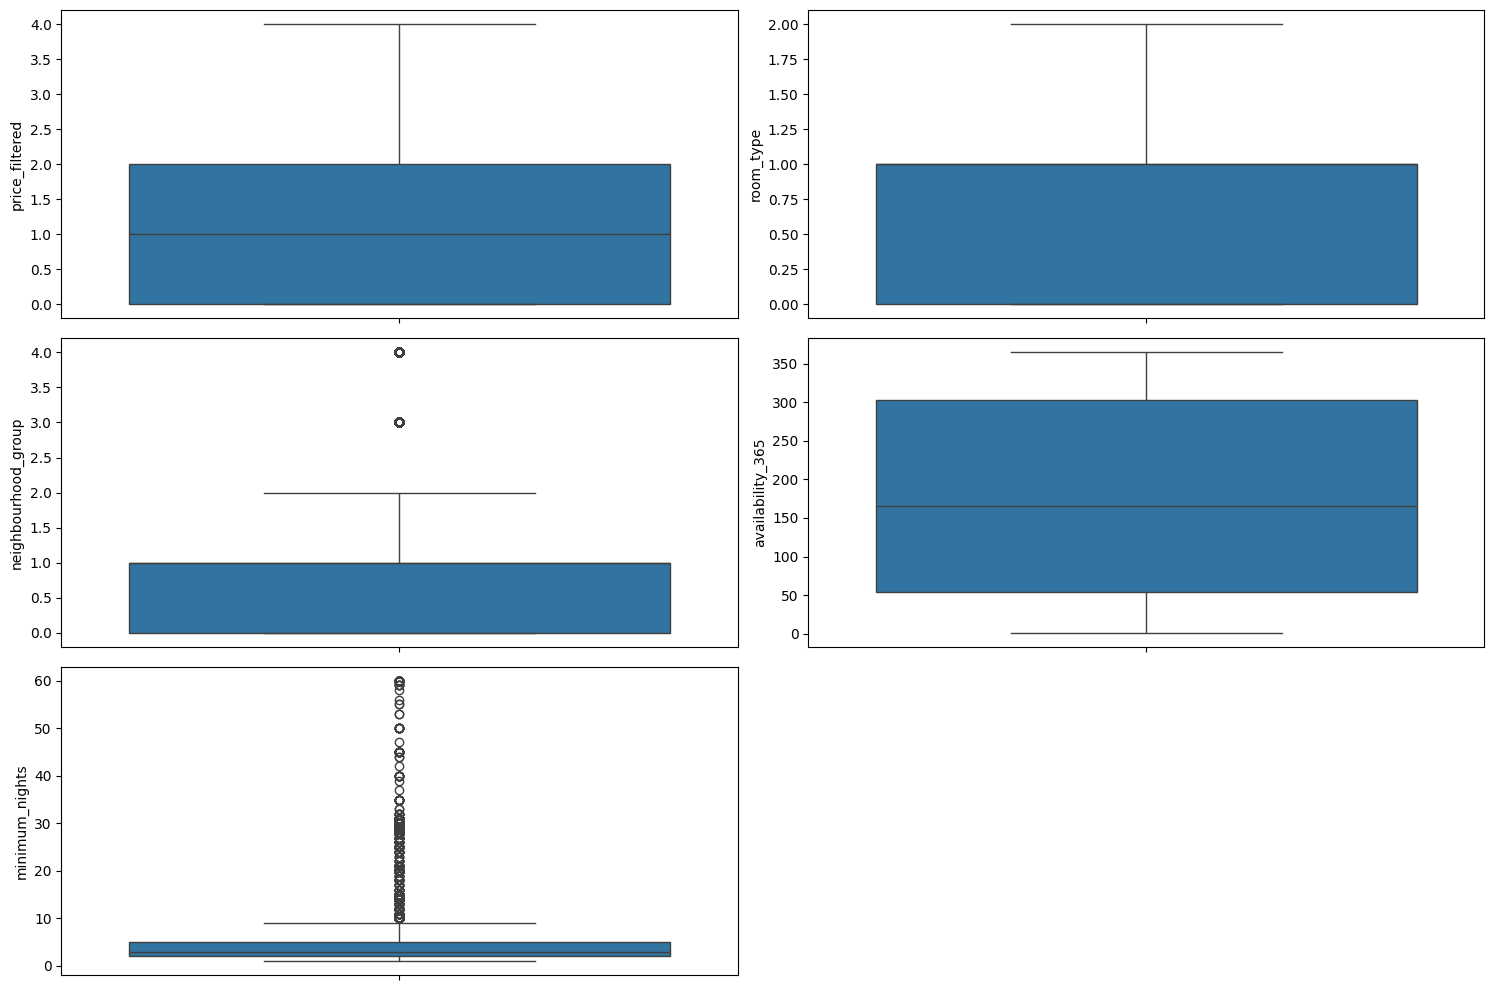

In [50]:
fig, axis = plt.subplots(3, 2, figsize=(15, 10))

sns.boxplot(ax=axis[0, 0], data=df, y="price_filtered")
sns.boxplot(ax=axis[0, 1], data=df, y="room_type")
sns.boxplot(ax=axis[1, 0], data=df, y="neighbourhood_group")
sns.boxplot(ax=axis[1, 1], data=df, y="availability_365")
sns.boxplot(ax=axis[2, 0], data=df, y="minimum_nights")

fig.delaxes(axis[2, 1])

plt.tight_layout()
plt.show()

**Variables afectadas por los outliers**

> *``neighbourhood_gruop``
> *``minimum_nights``


In [61]:
# Calculo el Rango inter Cuartil: IQR = Q3(75%) - Q1(25%)
q1 = df["minimum_nights"].quantile(0.25)
q3 = df["minimum_nights"].quantile(0.75)
iqr = q3 - q1

# Definir los límites inferior y superior
lower_limit = 0 if (q1 - 1.5 * iqr) < 0 else q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

f"Límites superior: {round(upper_limit, 2)}, límite inferior: {round(lower_limit, 2)}, rango intercuartílico: {round(iqr, 2)}"

'Límites superior: 9.5, límite inferior: 0, rango intercuartílico: 3.0'

In [62]:
# Calculo el Rango inter Cuartil: IQR = Q3(75%) - Q1(25%)
q1 = df["neighbourhood_group"].quantile(0.25)
q3 = df["neighbourhood_group"].quantile(0.75)
iqr = q3 - q1

# Definir los límites inferior y superior
lower_limit = 0 if (q1 - 1.5 * iqr) < 0 else q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

f"Límites superior: {round(upper_limit, 2)}, límite inferior: {round(lower_limit, 2)}, rango intercuartílico: {round(iqr, 2)}"

'Límites superior: 2.5, límite inferior: 0, rango intercuartílico: 1.0'

In [67]:
df[df['minimum_nights'] >10]

,neighbourhood_group,room_type,price,minimum_nights,availability_365,price_filtered,room_type_n,neighbourhood_group_n
29,1,1,180,14,67,0,1,1
36,0,0,35,60,365,3,0,0
45,0,1,150,29,95,0,1,0
55,0,1,150,30,30,0,1,0
59,1,1,180,30,154,0,1,1
...,...,...,...,...,...,...,...,...
48810,1,0,75,30,90,2,0,1
48843,0,0,45,29,341,3,0,0
48871,1,0,35,29,31,3,0,1
48879,0,1,120,20,22,0,1,0


> * Se observa que la mayoría de los anuncios disponibles más de diez noches se encuentran en los grupos:
> 1. room_type 0 o 1 que pertenecen a los rangos de precio del 0 hasta 100$ por noche
> 2. neighbouthood_group 0 o 1 que son Brooklyn y Manhattan

FUNCION ``.quantile(0-1%)``

In [68]:
price_stats = df ['price'].describe()
price_stats

count    30783.000000
mean       145.531365
std        113.940672
min         10.000000
25%         70.000000
50%        110.000000
75%        185.000000
max        822.000000
Name: price, dtype: float64

**Observaciones:**
No sé analizar las conclusiones estadisticas

#### **Análisis de variables faltantes:**

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30783 entries, 0 to 48894
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   neighbourhood_group    30783 non-null  int64
 1   room_type              30783 non-null  int64
 2   price                  30783 non-null  int64
 3   minimum_nights         30783 non-null  int64
 4   availability_365       30783 non-null  int64
 5   price_filtered         30783 non-null  int64
 6   room_type_n            30783 non-null  int64
 7   neighbourhood_group_n  30783 non-null  int64
dtypes: int64(8)
memory usage: 3.1 MB


In [ ]:
# Porcentaje de valores faltantes
df.isnull().sum().sort_values(ascending=False) / len(df)

neighbourhood_group    0.0
room_type              0.0
price                  0.0
minimum_nights         0.0
availability_365       0.0
price_lvl              0.0
dtype: float64

**Reemplazar valores**

> * No hace falta porque no hay valores nulos en las variables seleccionadas

In [ ]:
df.isnull().sum()

neighbourhood_group    0
room_type              0
price                  0
minimum_nights         0
availability_365       0
price_lvl              0
dtype: int64

## **Split**

In [ ]:
df.shape

(47975, 6)

**Dividir el conjnto entre train y test**

In [70]:
# División del conjunto de datos en muestras de train y test
X = df.drop("price_filtered", axis=1)
y = df["price_filtered"]

# sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

In [52]:
X_train, X_test, y_train, y_test

(       neighbourhood_group  room_type  price  minimum_nights  \
 26033                    1          0     50               4   
 2151                     1          1     97               3   
 44151                    0          1    100               3   
 45829                    1          1    200               1   
 31                       1          0     52               2   
 ...                    ...        ...    ...             ...   
 2300                     0          0     80               2   
 4110                     2          1     95               3   
 43464                    0          1    499               2   
 47016                    4          2     57               1   
 45932                    1          1    100              29   
 
        availability_365  room_type_n  neighbourhood_group_n  
 26033                42            0                      1  
 2151                  6            1                      1  
 44151                 6     

## **Escalado de valores:**

**Normlización**

In [53]:
# TODO: Realizar el escalando con el dataset dividido (ahora lo estamos haciendo completo)
norm_scaler = StandardScaler()  # Instancia de: from sklearn.preprocessing import StandardScaler

num_variables = ["price_filtered", "minimum_nights", "availability_365"]
norm_features = norm_scaler.fit_transform(df[num_variables])

df_norm = pd.DataFrame(norm_features,
                       index=df.index,
                       columns=num_variables)
df_norm.head()

,price_filtered,minimum_nights,availability_365
0,-1.244963,-0.582906,1.511410
1,-0.360829,-0.582906,1.432025
2,-1.244963,-0.383894,1.511410
3,0.523306,-0.582906,0.153940
5,-0.360829,-0.383894,-0.362057


In [54]:
df_norm

,price_filtered,minimum_nights,availability_365
0,-1.244963,-0.582906,1.511410
1,-0.360829,-0.582906,1.432025
2,-1.244963,-0.383894,1.511410
3,0.523306,-0.582906,0.153940
5,-0.360829,-0.383894,-0.362057
...,...,...,...
48890,0.523306,-0.483400,-1.314667
48891,1.407441,-0.284388,-1.100330
48892,-1.244963,0.312647,-1.171775
48893,1.407441,-0.582906,-1.370236


**Escalado mínimo máximo**

In [ ]:
Realizar el escalando con el dataset dividido (ahora lo estamos haciendo completo)
min_max_scaler = MinMaxScaler()  # Instancia de: from sklearn.preprocessing import MinMaxScaler

num_variables = ["price_filtered", "minimum_nights", "availability_365"]
min_max_features = min_max_scaler.fit_transform(df[num_variables])

df_min_max = pd.DataFrame(min_max_features,
                          index=df.index,
                          columns=num_variables)
df_min_max

,price_filtered,minimum_nights,availability_365
0,0.00,0.000000,1.000000
1,0.25,0.000000,0.972527
2,0.00,0.033898,1.000000
3,0.50,0.000000,0.530220
5,0.25,0.033898,0.351648
...,...,...,...
48890,0.50,0.016949,0.021978
48891,0.75,0.050847,0.096154
48892,0.00,0.152542,0.071429
48893,0.75,0.000000,0.002747


#### **Encoding**

**Label encoding**

TODO
cambiar nombres de las variables


In [56]:
# 0. Creamos copias de los conjuntos de entrenamiento: X_train | X_test
X_train_cat_le = X_train.copy()
X_test_cat_le = X_test.copy()

# 1. Creamos las instancias del encoder
label_encoder_sex = LabelEncoder()
# 2. Entrenamos los encoders con los datos de entrenamiento (ajustamos) fit
label_encoder_sex.fit(X_train['room_type'])
# 3. Aplicamos el encoder en ambos conjuntos (entrenamiento y test) transform
X_train_cat_le['room_type_le'] = label_encoder_sex.transform(X_train['room_type'])
X_test_cat_le['room_type_le'] = label_encoder_sex.transform(X_test['room_type'])


# 1. Creamos las instancias del encoder
label_encoder_embarked = LabelEncoder()
# 2. Entrenamos los encoders con los datos de entrenamiento (ajustamos) utilizamos: fit()
label_encoder_embarked.fit(X_train['neighbourhood_group'])
# 3. Aplicamos el encoder en ambos conjuntos (entrenamiento y test) transform
X_train_cat_le['neighbourhood_group_le'] = label_encoder_embarked.transform(X_train['neighbourhood_group'])  # 3.1 train
X_test_cat_le['neighbourhood_group_le'] = label_encoder_embarked.transform(X_test['neighbourhood_group'])  # 3.2 test


X_train_cat_le.head()

,neighbourhood_group,room_type,price,minimum_nights,availability_365,room_type_n,neighbourhood_group_n,room_type_le,neighbourhood_group_le
26033,1,0,50,4,42,0,1,0,1
2151,1,1,97,3,6,1,1,1,1
44151,0,1,100,3,6,1,0,1,0
45829,1,1,200,1,157,1,1,1,1
31,1,0,52,2,255,0,1,0,1


**One-hot encoder**

In [57]:
# Genero una lista con los nombres de las columnas categóricas
cat_variables = ["room_type", "neighbourhood_group"]

# Creamos la instancia del encoder
onehot_encoder = OneHotEncoder(sparse_output=False)

# Entrenamos el encoder con los datos de entrenamiento (ajustamos)
onehot_encoder.fit(X_train[cat_variables])

# Aplicamos el encoder en el conjunto de entrenamiento: X_train
X_train_cat_ohe = onehot_encoder.transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe,
                               index=X_train.index,
                               columns=onehot_encoder.get_feature_names_out(cat_variables))

# Aplicamos el encoder en el conjunto de test: X_test
X_test_cat_ohe = onehot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe,
                              index=X_test.index,
                              columns=onehot_encoder.get_feature_names_out(cat_variables))

X_train_cat_ohe.head()

,room_type_0,room_type_1,room_type_2,neighbourhood_group_0,neighbourhood_group_1,neighbourhood_group_2,neighbourhood_group_3,neighbourhood_group_4
26033,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2151,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
44151,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
45829,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
31,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


**Ordinal encoding**

In [58]:
# Genero una lista con los nombres de las columnas categóricas
cat_variables = ["room_type", "neighbourhood_group"]

# Creamos la instancia del encoder
onehot_encoder = OneHotEncoder(sparse_output=False)

# Entrenamos el encoder con los datos de entrenamiento (ajustamos)
onehot_encoder.fit(X_train[cat_variables])

# Aplicamos el encoder en el conjunto de entrenamiento: X_train
X_train_cat_ohe = onehot_encoder.transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe,
                               index=X_train.index,
                               columns=onehot_encoder.get_feature_names_out(cat_variables))

# Aplicamos el encoder en el conjunto de test: X_test
X_test_cat_ohe = onehot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe,
                              index=X_test.index,
                              columns=onehot_encoder.get_feature_names_out(cat_variables))

X_train_cat_ohe.head()

,room_type_0,room_type_1,room_type_2,neighbourhood_group_0,neighbourhood_group_1,neighbourhood_group_2,neighbourhood_group_3,neighbourhood_group_4
26033,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2151,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
44151,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
45829,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
31,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


#### **Crear json y pikle: Guardo losscales & encoders**

In [59]:
# Guardamos utilizando Pickle (que nos permite guardar objetos de Python)
with open('../models/00-eda-airbnb-ny.pkl', 'wb') as file:
    pickle.dump(onehot_encoder, file)